**Analyse de performance de YOLO:**

Dans ce notebook, le but est d'analyser la performance du Yolo dans les trois essais qu'on a fait.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [41]:
# Monter le Google Drive et lire le dataset

from google.colab import drive

drive.mount('/content/drive')

archive_path = "/content/drive/MyDrive/dataset"
data_path = os.path.join(archive_path, "data")
csv_path = os.path.join(archive_path, "meta_df.csv")

df = pd.read_csv(csv_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
# Resultats des trois essais

# Essai 1
essai1 = pd.DataFrame({
    "class": [
        "Aluminium foil", "Blister pack", "Bottle", "Bottle cap", "Broken glass",
        "Can", "Carton", "Cigarette", "Cup", "Lid", "Other plastic", "Paper",
        "Paper bag", "Plastic bag & wrapper", "Plastic container", "Plastic utensils",
        "Pop tab", "Rope & strings", "Scrap metal", "Straw", "Styrofoam piece",
        "Unlabeled litter"
    ],
    "instances": [13, 1, 61, 42, 5, 62, 40, 76, 27, 15, 23, 27, 5, 129, 12, 5, 20, 1, 11, 18, 15, 55],
    "mAP50":     [0.591, 0.249, 0.464, 0.326, 0.000, 0.451, 0.192, 0.007, 0.235, 0.116, 0.053, 0.191,
                  0.125, 0.409, 0.142, 0.044, 0.075, 0.013, 0.002, 0.155, 0.249, 0.043],
    "groupe":    [
        "Metal", "Plastic", "Plastic", "Plastic", "Glass",
        "Metal", "Paper", "Other", "Plastic", "Plastic", "Plastic", "Paper",
        "Paper", "Plastic", "Plastic", "Plastic",
        "Metal", "Other", "Metal", "Plastic", "Plastic",
        "Other"
    ]
})

# Essai 2
essai2 = pd.DataFrame({
    "class":     ["Plastic", "Metal", "Paper", "Glass", "Other"],
    "instances": [348, 106, 72, 5, 132],
    "mAP50":     [0.435, 0.310, 0.258, 0.001, 0.055]
})

# Essai 3
essai3 = pd.DataFrame({
    "class":     ["Plastic", "Metal", "Paper", "Glass", "Other"],
    "instances": [348, 106, 72, 5, 132],
    "mAP50":     [0.455, 0.414, 0.241, 0.000, 0.111]
})

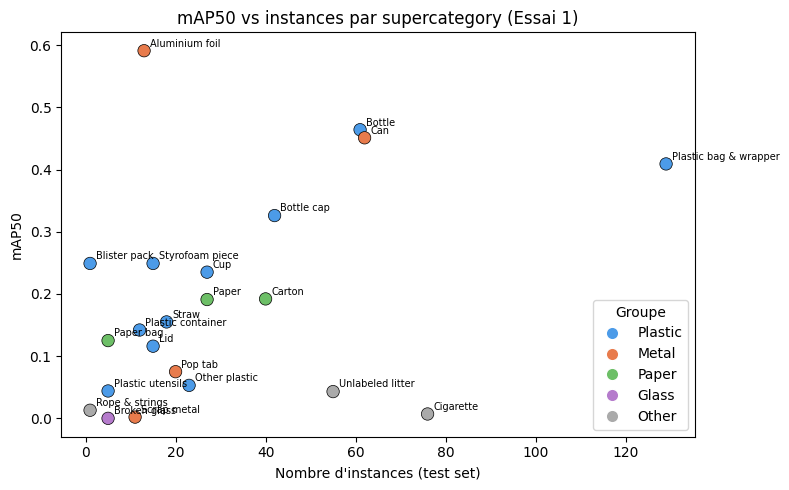

In [43]:
# Figure 1: mAP50 par supercategory vs nombre d'instances (Essai 1)

fig, ax = plt.subplots(figsize=(8, 5))
color_map = essai1["groupe"].map({
    "Plastic": "#4C9BE8", "Metal": "#E87B4C", "Paper": "#6DBF67",
    "Glass": "#B57BCC", "Other": "#AAAAAA"
})
ax.scatter(essai1["instances"], essai1["mAP50"], c=color_map, s=80, edgecolors="k", linewidths=0.5)
for _, row in essai1.iterrows():
    ax.annotate(row["class"], (row["instances"], row["mAP50"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Nombre d'instances (test set)")
ax.set_ylabel("mAP50")
ax.set_title("mAP50 vs instances par supercategory (Essai 1)")
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=9)
           for c in ["#4C9BE8","#E87B4C","#6DBF67","#B57BCC","#AAAAAA"]]
ax.legend(handles, ["Plastic","Metal","Paper","Glass","Other"], title="Groupe")
plt.tight_layout()
plt.show()

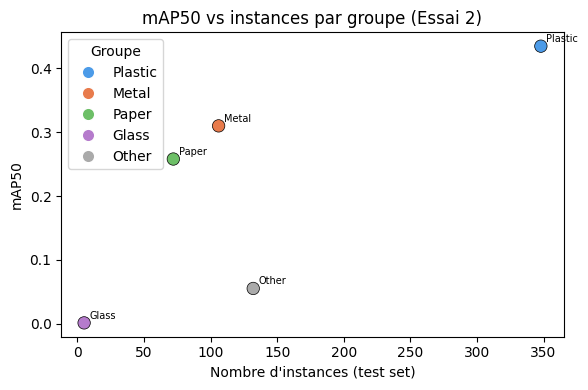

In [44]:
# Figure: mAP50 vs instances par groupe (Essai 2)

fig, ax = plt.subplots(figsize=(6, 4))
color_map = essai2["class"].map({
    "Plastic": "#4C9BE8", "Metal": "#E87B4C", "Paper": "#6DBF67",
    "Glass": "#B57BCC", "Other": "#AAAAAA"
})
ax.scatter(essai2["instances"], essai2["mAP50"], c=color_map, s=80, edgecolors="k", linewidths=0.5)
for _, row in essai2.iterrows():
    ax.annotate(row["class"], (row["instances"], row["mAP50"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Nombre d'instances (test set)")
ax.set_ylabel("mAP50")
ax.set_title("mAP50 vs instances par groupe (Essai 2)")
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=9)
           for c in ["#4C9BE8","#E87B4C","#6DBF67","#B57BCC","#AAAAAA"]]
ax.legend(handles, ["Plastic","Metal","Paper","Glass","Other"], title="Groupe")
plt.tight_layout()
plt.show()

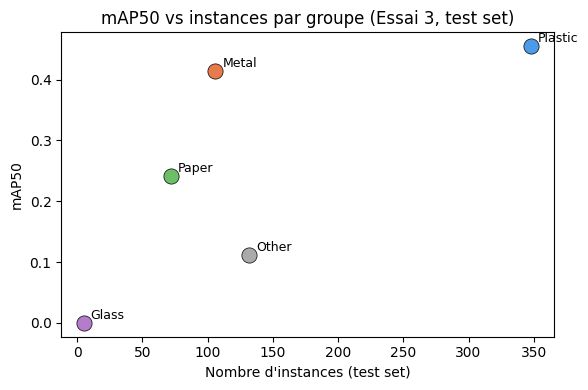

In [45]:
# Figure 4: Relation mAP50/instances pour les groupes (Essai 3)

fig, ax = plt.subplots(figsize=(6, 4))
group_colors = ["#4C9BE8", "#E87B4C", "#6DBF67", "#B57BCC", "#AAAAAA"]
for i, row in essai3.iterrows():
    ax.scatter(row["instances"], row["mAP50"], s=120, color=group_colors[i],
               edgecolors="k", linewidths=0.5, zorder=3)
    ax.annotate(row["class"], (row["instances"], row["mAP50"]),
                fontsize=9, xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("Nombre d'instances (test set)")
ax.set_ylabel("mAP50")
ax.set_title("mAP50 vs instances par groupe (Essai 3, test set)")
plt.tight_layout()
plt.show()

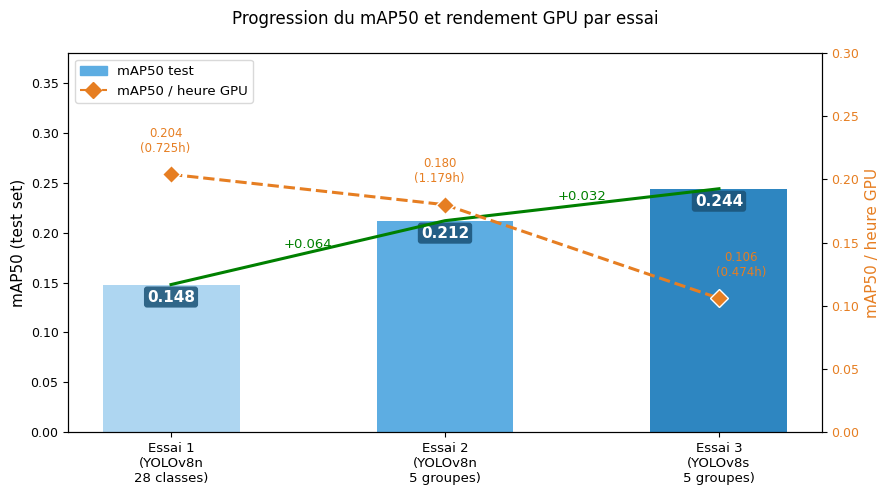

In [46]:
# Données des trois essais
essais = ["Essai 1\n(YOLOv8n\n28 classes)", "Essai 2\n(YOLOv8n\n5 groupes)", "Essai 3\n(YOLOv8s\n5 groupes)"]
map50 = [0.148, 0.212, 0.244]
map50_par_heure = [0.204, 0.180, 0.106]
heures_gpu = [0.725, 1.179, 0.474]

x = np.arange(len(essais))

fig, ax1 = plt.subplots(figsize=(9, 5))
bars = ax1.bar(x, map50, color=["#AED6F1", "#5DADE2", "#2E86C1"], width=0.5, zorder=2)

for bar, val in zip(bars, map50):
    ax1.text(bar.get_x() + bar.get_width()/2, val - 0.02, f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='white', bbox=dict(boxstyle='round,pad=0.2', facecolor='#1A5276', edgecolor='none', alpha=0.85))

ax1.plot(x, map50, color='green', linewidth=2.2, zorder=3)
ax1.annotate('+0.064', xy=(0.5, (map50[0]+map50[1])/2 + 0.005), fontsize=9.5, color='green', ha='center')
ax1.annotate('+0.032', xy=(1.5, (map50[1]+map50[2])/2 + 0.005), fontsize=9.5, color='green', ha='center')


ax1.set_ylabel("mAP50 (test set)", fontsize=11)
ax1.set_ylim(0, 0.38)
ax1.set_xticks(x)
ax1.set_xticklabels(essais, fontsize=9.5)
ax1.yaxis.set_tick_params(labelsize=9)

ax2 = ax1.twinx()
ax2.plot(x, map50_par_heure, color='#E67E22', linestyle='--', linewidth=2.2, marker='D', markersize=9, markerfacecolor='#E67E22', markeredgecolor='white', zorder=4)

annotations = [(0, map50_par_heure[0], "0.204\n(0.725h)"),(1, map50_par_heure[1], "0.180\n(1.179h)"),(2, map50_par_heure[2], "0.106\n(0.474h)"),]
offsets = [(-0.02, 0.018), (-0.02, 0.018), (0.08, 0.018)]
for i, (xi, yi, label) in enumerate(annotations):
    ax2.annotate(label, xy=(xi, yi), xytext=(xi + offsets[i][0], yi + offsets[i][1]), fontsize=8.5, color='#E67E22', ha='center')

ax2.set_ylabel("mAP50 / heure GPU", fontsize=11, color='#E67E22')
ax2.tick_params(axis='y', labelcolor='#E67E22', labelsize=9)
ax2.set_ylim(0, 0.30)

bar_patch = mpatches.Patch(color='#5DADE2', label='mAP50 test')
line_patch = plt.Line2D([0],[0], color='#E67E22', linestyle='--', marker='D', markersize=8, label='mAP50 / heure GPU')
ax1.legend(handles=[bar_patch, line_patch], loc='upper left', fontsize=9.5, framealpha=0.85, edgecolor='lightgray')

fig.suptitle("Progression du mAP50 et rendement GPU par essai")

plt.tight_layout()
plt.show()

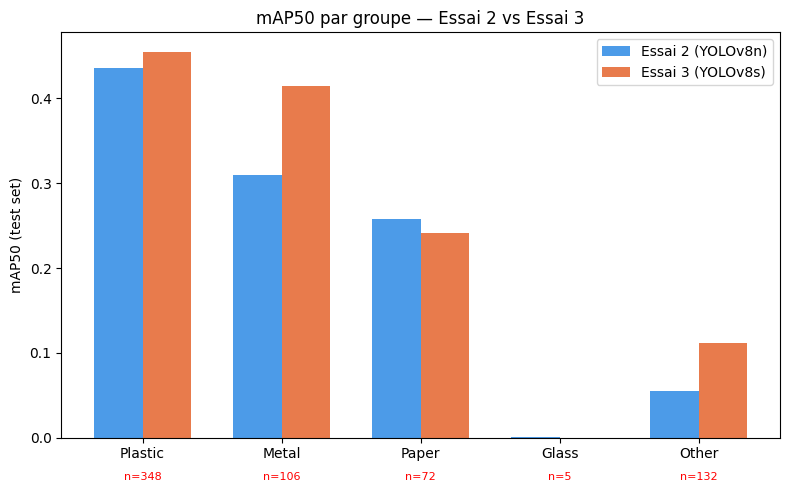

In [47]:
# Figure 2: mAP50 par groupe, comparaison Essai 2 vs Essai 3

x = np.arange(len(essai2))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, essai2["mAP50"], width, label="Essai 2 (YOLOv8n)", color="#4C9BE8")
ax.bar(x + width/2, essai3["mAP50"], width, label="Essai 3 (YOLOv8s)", color="#E87B4C")
ax.set_xticks(x)
ax.set_xticklabels(essai2["class"])
ax.set_ylabel("mAP50 (test set)")
ax.set_title("mAP50 par groupe — Essai 2 vs Essai 3")
ax.legend()

for i, row in essai2.iterrows():
    ax.text(i, -0.05, f"n={row['instances']}", ha='center', fontsize=8, color='red')

plt.tight_layout()
plt.show()

In [48]:
# Resume textuel

print("Resume par groupe (test set):\n")
summary = essai3.copy()
summary["mAP50_essai2"] = essai2["mAP50"].values
summary["delta"] = summary["mAP50"] - summary["mAP50_essai2"]
summary = summary[["class", "instances", "mAP50_essai2", "mAP50", "delta"]]
summary.columns = ["Groupe", "Instances", "mAP50 Essai2", "mAP50 Essai3", "Delta"]
print(summary.to_string(index=False))

Resume par groupe (test set):

 Groupe  Instances  mAP50 Essai2  mAP50 Essai3  Delta
Plastic        348         0.435         0.455  0.020
  Metal        106         0.310         0.414  0.104
  Paper         72         0.258         0.241 -0.017
  Glass          5         0.001         0.000 -0.001
  Other        132         0.055         0.111  0.056


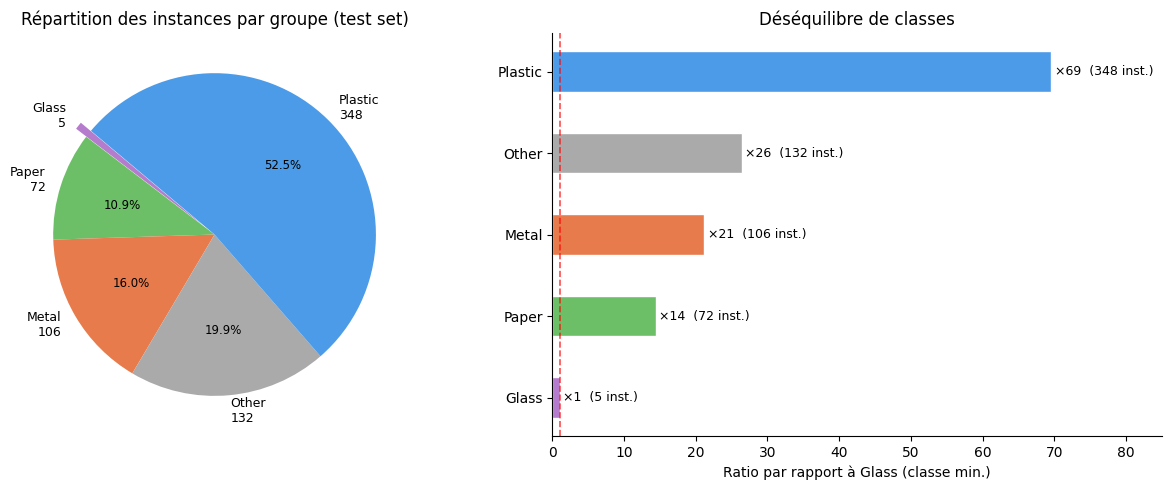

In [52]:
#Déséquilibre de classes

groupes = ["Glass", "Paper", "Metal", "Other", "Plastic"]
instances= [5, 72, 106, 132, 348]
total= sum(instances)
couleurs= {"Plastic": "#4C9BE8", "Metal": "#E87B4C", "Paper": "#6DBF67","Glass": "#B57BCC", "Other": "#AAAAAA"}

fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))

labels_pie= ["Glass\n5", "Paper\n72", "Metal\n106", "Other\n132", "Plastic\n348"]
sizes  = [5, 72, 106, 132, 348]
colors_pie= [couleurs[g] for g in groupes]
explode= [0.08, 0, 0, 0, 0]  # mettre Glass en évidence

wedges, texts, autotexts = ax_pie.pie(sizes, labels=labels_pie, colors=colors_pie,autopct=lambda p: f"{p:.1f}%" if p > 1 else "",startangle=140, explode=explode,textprops={"fontsize": 9})
for at in autotexts:
    at.set_fontsize(8.5)
ax_pie.set_title("Répartition des instances par groupe (test set)")

ratios      = [inst / 5 for inst in instances]  # base = Glass (5 instances)
bar_colors  = [couleurs[g] for g in groupes]

bars = ax_bar.barh(groupes, ratios, color=bar_colors, edgecolor='white', height=0.5)
for bar, ratio, inst in zip(bars, ratios, instances):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"×{int(ratio)}  ({inst} inst.)", va='center', fontsize=9)

ax_bar.axvline(x=1, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax_bar.set_xlabel("Ratio par rapport à Glass (classe min.)")
ax_bar.set_title("Déséquilibre de classes")
ax_bar.set_xlim(0, 85)
ax_bar.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

L'analyse en detail sera faite dans le rapport.